# Moral Machine Reanalysis: Intervention Effect

The Moral Machine experiment (Awad et al., 2018) collected large-scale judgments about unavoidable autonomous-vehicle crashes, where each scenario had two outcomes depending on whether the car **swerves** or **stays on course**. In the paper's Judge mode, users selected which outcome they found preferable.

The design randomized multiple factors simultaneously. In the Supplementary description, the authors list three randomized scenario dimensions that were always varied with character attributes: **interventionism**, **relation to the AV**, and **legality**. They also describe interventionism as randomizing which group is spared if the car does nothing (stays on course).

This notebook isolates the intervention variable only. Here, `Intervention` measures whether the morally relevant trade-off is attached to **taking action (swerving)** versus **not taking action (staying)**. With this coding:
- `Intervention = 1`: passengers die if the AV swerves.
- `Intervention = 0`: passengers die if the AV stays in lane.

So the intervention AMCE is the causal shift in choice probability when the same type of dilemma is framed with a different action/inaction structure (swerve versus stay), averaging over the other randomized attributes.


### Imports


In [92]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats

repo_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if os.path.isdir(os.path.join(os.getcwd(), 'ppi_py')):
    repo_root = os.getcwd()
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from ppi_py import ppi_ols_ci, classical_ols_ci, ppi_ols_pointestimate
from ppi_py.ppi import _ols_get_stats
from ppi_py.datasets import load_dataset


### Load reduced dataset

This follows the pattern used in other examples: data are loaded via `load_dataset`,
which downloads `moralmachine.npz` to `./data/` from Google Drive if needed.


In [93]:
dataset_folder = './data/'
data = load_dataset(dataset_folder, 'moralmachine')

y = str(data['Yhat_name'])
df = pd.DataFrame({
    'UserID': data['UserID'].astype(str),
    'ResponseID': data['ResponseID'].astype(str),
    'weights': data['weights'],
    'Intervention': data['Intervention'],
    'Saved': data['Saved'],
    y: data['Yhat'],
})

print("Number of respondents: ", len(df["UserID"].unique()))
print("Number of scenarios: ", len(df["ResponseID"].unique()))
print("Number of options per scenario: ", df["ResponseID"].value_counts().unique()[0])
print("Avg. number of scenarios per respondent: ", round(df.groupby("UserID")["ResponseID"].count().mean()/2,1))
print("Number of rows:", df.shape[0])
print("Number of NAs in observed dependent variable: ", df["Saved"].isna().sum())
print("Number of NAs in predicted dependent variable with GPT4 Turbo: ", df["gpt4turbo_wp_Saved"].isna().sum())
print(f"Dataset loaded. Sample size: {len(df)}")
df.head()



Number of respondents:  54695
Number of scenarios:  581981
Number of options per scenario:  2
Avg. number of scenarios per respondent:  10.6
Number of rows: 1163962
Number of NAs in observed dependent variable:  0
Number of NAs in predicted dependent variable with GPT4 Turbo:  0
Dataset loaded. Sample size: 1163962


,UserID,ResponseID,weights,Intervention,Saved,gpt4turbo_wp_Saved
0,4510867385040810.0,DujZ9eRFSejca6Zsd,4.340278,0,0,0
1,4510867385040810.0,DujZ9eRFSejca6Zsd,4.340278,1,1,1
2,4073176426704480.0,uRgKdpQYg7bAEb9px,6.510417,0,1,1
3,4073176426704480.0,uRgKdpQYg7bAEb9px,6.510417,1,0,0
4,8930084739195530.0,BrZGg5AWoDSMPisDZ,9.765625,0,0,0


### True Parameter (Full Data, Clustered WLS)


In [94]:
alpha = 0.05

dd_true = df.dropna(subset=['Saved']).copy()
X_full = sm.add_constant(dd_true['Intervention'])
fit_true = sm.WLS(dd_true['Saved'], X_full, weights=dd_true['weights']).fit(
    cov_type='cluster',
    cov_kwds={'groups': dd_true['UserID']}
)
true_beta = fit_true.params['Intervention']

print(f'True beta (Intervention): {true_beta:.6f}')


True beta (Intervention): 0.081441


### Coverage Simulation


In [95]:
n_users = 500
K = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 10.0, 15.0, 20.0]
reps = 500
rng = np.random.default_rng(2026)

print('n_users =', n_users)
print('K =', K)
print('reps =', reps)


n_users = 500
K = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 10.0, 15.0, 20.0]
reps = 500


In [96]:
def one_draw_coverage(df, y_col, true_beta, n_users, k, alpha, rng):
    user_ids = df['UserID'].unique()
    N_users = int(round(k * n_users))

    labeled_users = rng.choice(user_ids, size=n_users, replace=False)
    remaining_users = user_ids[~np.isin(user_ids, labeled_users)]
    unlabeled_users = rng.choice(remaining_users, size=N_users, replace=False)

    labeled = df[df['UserID'].isin(labeled_users)].dropna(subset=['Saved', y_col]).copy()
    unlabeled = df[df['UserID'].isin(unlabeled_users)].dropna(subset=[y_col]).copy()

    X = np.column_stack((np.ones(len(labeled)), labeled['Intervention'].to_numpy()))
    Y = labeled['Saved'].to_numpy()
    Yhat = labeled[y_col].to_numpy()

    X_unlabeled = np.column_stack((np.ones(len(unlabeled)), unlabeled['Intervention'].to_numpy()))
    Yhat_unlabeled = unlabeled[y_col].to_numpy()

    w = labeled['weights'].to_numpy()
    w_unlabeled = unlabeled['weights'].to_numpy()

    lower_no, upper_no = ppi_ols_ci(
        X=X,
        Y=Y,
        Yhat=Yhat,
        X_unlabeled=X_unlabeled,
        Yhat_unlabeled=Yhat_unlabeled,
        alpha=alpha,
        coord=1,
        lam=None,
        w=w,
        w_unlabeled=w_unlabeled,
    )

    group = pd.factorize(labeled['UserID'], sort=False)[0]
    group_unlabeled = pd.factorize(unlabeled['UserID'], sort=False)[0]

    lower_cluster, upper_cluster = ppi_ols_ci(
        X=X,
        Y=Y,
        Yhat=Yhat,
        X_unlabeled=X_unlabeled,
        Yhat_unlabeled=Yhat_unlabeled,
        alpha=alpha,
        coord=1,
        lam=None,
        w=w,
        w_unlabeled=w_unlabeled,
        group=group,
        group_unlabeled=group_unlabeled,
    )

    cover_no = (lower_no[1] <= true_beta) and (true_beta <= upper_no[1])
    cover_cluster = (lower_cluster[1] <= true_beta) and (true_beta <= upper_cluster[1])

    return cover_cluster, cover_no


In [97]:
single_cluster, single_no = one_draw_coverage(df, y, true_beta, n_users, 1.0, alpha, rng)
print('Single draw check (K=1) - cover with clusters:', single_cluster)
print('Single draw check (K=1) - cover without clusters:', single_no)

rows = []
for k in K:
    cover_cluster_vals = []
    cover_no_vals = []

    for _ in range(reps):
        cover_cluster, cover_no = one_draw_coverage(df, y, true_beta, n_users, k, alpha, rng)
        cover_cluster_vals.append(cover_cluster)
        cover_no_vals.append(cover_no)

    rows.append({
        'K': k,
        'coverage_cluster': np.mean(cover_cluster_vals),
        'coverage_no_cluster': np.mean(cover_no_vals),
    })

coverage_results = pd.DataFrame(rows)
coverage_results


Single draw check (K=1) - cover with clusters: True
Single draw check (K=1) - cover without clusters: True


,K,coverage_cluster,coverage_no_cluster
0,0.25,0.958,0.850
1,0.50,0.948,0.824
2,0.75,0.960,0.844
3,1.00,0.942,0.818
4,2.00,0.960,0.856
5,3.00,0.960,0.828
6,4.00,0.958,0.830
7,5.00,0.950,0.834
8,10.00,0.946,0.836
9,15.00,0.938,0.824


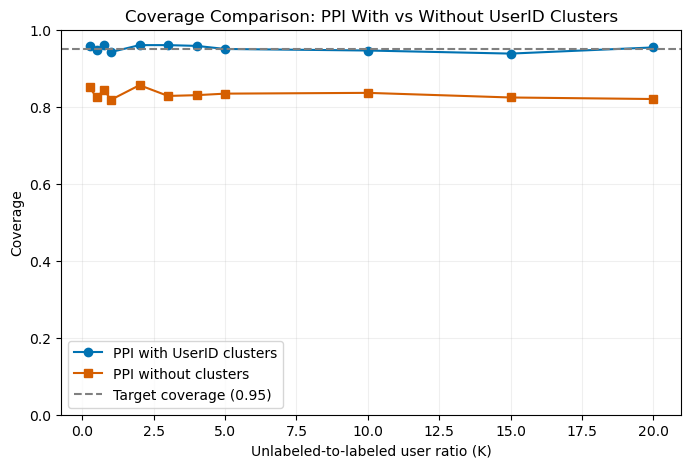

In [98]:
plt.figure(figsize=(8, 5))
plt.plot(
    coverage_results['K'],
    coverage_results['coverage_cluster'],
    marker='o',
    color='#0072B2',
    label='PPI with UserID clusters',
)
plt.plot(
    coverage_results['K'],
    coverage_results['coverage_no_cluster'],
    marker='s',
    color='#D55E00',
    label='PPI without clusters',
)
plt.axhline(0.95, linestyle='--', color='gray', label='Target coverage (0.95)')
plt.ylim(0, 1)
plt.xlabel('Unlabeled-to-labeled user ratio (K)')
plt.ylabel('Coverage')
plt.title('Coverage Comparison: PPI With vs Without UserID Clusters')
plt.grid(alpha=0.2)
plt.legend()
plt.show()
